In [10]:
import pandas as pd 

In [11]:
df = pd.read_csv("C:/Users/Mahakdeep Kaur/Downloads/train.csv")
   
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [12]:
df = df.drop(columns=['Cabin'])

In [13]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [14]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [15]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])       
df['Embarked'] = encoder.fit_transform(df['Embarked']) 

In [16]:
print(df.head())  

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  Embarked  
0         A/5 21171   7.2500         2  
1          PC 17599  71.2833         0  
2  STON/O2. 3101282   7.9250         2  
3            113803  53.1000         2  
4            373450   8.0500         2  


In [17]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X = df[['Pclass','Sex','Age','Fare','Embarked','SibSp','Parch']]

y = df['Survived']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (712, 7)
Testing set size: (179, 7)


In [21]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
y_pred = model.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8100558659217877


In [25]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[90 15]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [26]:
import pandas as pd
sample_passenger = pd.DataFrame([[3, 1, 22, 7.25, 2, 0, 0]],
                                columns=['Pclass','Sex','Age','Fare','Embarked','SibSp','Parch'])
prediction = model.predict(sample_passenger)
print("Survived?", prediction[0])

Survived? 0


In [27]:
new_passengers = pd.DataFrame([
    [1, 0, 25, 71.2833, 1, 1, 0],   
    [3, 1, 22, 7.25, 2, 0, 0],      
    [2, 0, 30, 12.35, 0, 0, 0]      
], columns=['Pclass','Sex','Age','Fare','Embarked','SibSp','Parch'])

predictions = model.predict(new_passengers)
print("Predictions:", predictions)


Predictions: [1 0 1]


In [28]:
import joblib
joblib.dump(model, "train_model.pkl")
loaded_model = joblib.load("train_model.pkl")

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

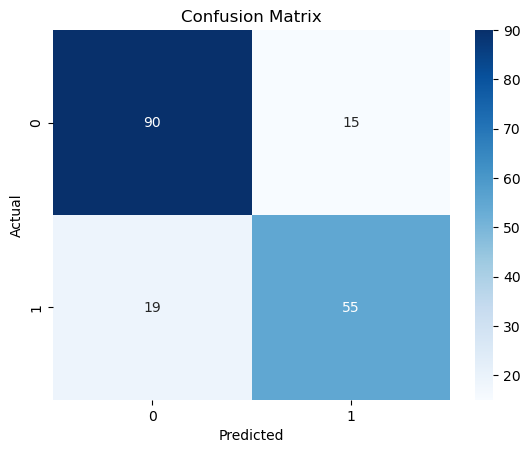

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8100558659217877


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



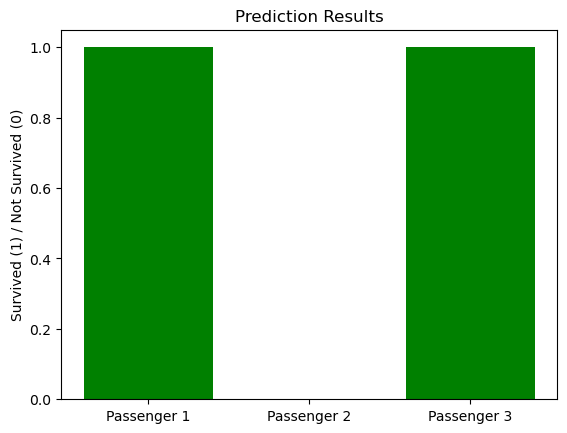

In [33]:
predictions = [1,0,1]   # Survived=1, Not Survived=0
plt.bar(["Passenger 1","Passenger 2","Passenger 3"], predictions, color=['green','red','green'])
plt.ylabel("Survived (1) / Not Survived (0)")
plt.title("Prediction Results")
plt.show()
